In [1]:
%load_ext autoreload
%autoreload 2

In [119]:
import torch
from typing import Any
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import combinations_with_replacement
from functools import reduce
import pyrtl
import pyrtl.simulation
from pyrtl.rtllib.libutils import twos_comp_repr
from pyrtl.rtllib.adders import carrysave_adder, kogge_stone
from IPython.display import display, Markdown, display_svg
from graphviz import render
from kai.src.float8 import Float8
from kai.src.bfloat16 import BF16

# Brain Float 16 (BF16) Format


BF16 is a 16-bit floating point format that maintains the same 8-bit exponent as IEEE 754 32-bit float (float32), but reduces precision by truncating the mantissa to 7 bits.


## Bit Layout


| Sign (1 bit) | Exponent (8 bits) | Mantissa (7 bits) |
| ------------ | ----------------- | ----------------- |
| bit 15       | bits 14-7         | bits 6-0          |

<br>

<table>
  <tr>
    <th>Bit Type</th>
    <td style="background-color: #ADD8E6; color: black; text-align: center;">S</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
  </tr>
  <tr>
    <th>Bit #</th>
    <td style="text-align: center;">15</td>
    <td style="text-align: center;">14</td>
    <td style="text-align: center;">13</td>
    <td style="text-align: center;">12</td>
    <td style="text-align: center;">11</td>
    <td style="text-align: center;">10</td>
    <td style="text-align: center;">9</td>
    <td style="text-align: center;">8</td>
    <td style="text-align: center;">7</td>
    <td style="text-align: center;">6</td>
    <td style="text-align: center;">5</td>
    <td style="text-align: center;">4</td>
    <td style="text-align: center;">3</td>
    <td style="text-align: center;">2</td>
    <td style="text-align: center;">1</td>
    <td style="text-align: center;">0</td>
  </tr>
</table>

The format follows this equation for normal numbers:
$$ (-1)^{\textstyle{sign}} × 2^{\text{exp} - 127} × (1 + \frac{\text{mantissa}}{2^7}) $$

For subnormal numbers (when exponent = 0):
$$ (-1)^{\textstyle{sign}} × 2^{-126} × (0 + \frac{\text{mantissa}}{2^7}) $$


## Key Constants


| Constant      | Sign | Exponent | Mantissa | Values ($\pm$ for +/-) | Calculation                                                             |
| ------------- | ---- | -------- | -------- | ---------------------- | ----------------------------------------------------------------------- |
| Zero          | x    | 00000000 | 0000000  | $\pm$ 0.0              | $0$                                                                     |
| Infinity      | x    | 11111111 | 0000000  | $\pm\infty$            | $\infty$                                                                |
| NaN           | x    | 11111111 | non-zero | Not a Number           | N/A                                                                     |
| Max Normal    | x    | 11111110 | 1111111  | $\pm$ 3.38e+38         | $2^{127} \times (1 + \frac{127}{128}) \approx 2^{127} \times 1.9921875$ |
| Min Normal    | x    | 00000001 | 0000000  | $\pm$ 1.18e-38         | $2^{-126} \times (1 + \frac{0}{128}) \approx 2^{-126} \times 1.0$       |
| Max Subnormal | x    | 00000000 | 1111111  | $\pm$ 1.17e-38         | $2^{-126} \times \frac{127}{128} \approx 2^{-126} \times 0.9921875$     |
| Min Subnormal | x    | 00000000 | 0000001  | $\pm$ 9.18e-41         | $2^{-126} \times \frac{1}{128} \approx 2^{-126} \times 0.0078125$       |


## Expected Outputs of Multiplication


| ×       | Zero | Inf | NaN | maxNorm | minNorm | maxSub | minSub | 1.0     |
| ------- | ---- | --- | --- | ------- | ------- | ------ | ------ | ------- |
| Zero    | 0    | NaN | NaN | 0       | 0       | 0      | 0      | 0       |
| Inf     | NaN  | Inf | NaN | Inf     | Inf     | Inf    | Inf    | Inf     |
| NaN     | NaN  | NaN | NaN | NaN     | NaN     | NaN    | NaN    | NaN     |
| maxNorm | 0    | Inf | NaN | Inf     | ~3.984  | ~3.953 | ~0.031 | maxNorm |
| minNorm | 0    | Inf | NaN | ~3.984  | 0       | 0      | 0      | minNorm |
| maxSub  | 0    | Inf | NaN | ~3.953  | 0       | 0      | 0      | maxSub  |
| minSub  | 0    | Inf | NaN | ~0.031  | 0       | 0      | 0      | minSub  |
| 1.0     | 0    | Inf | NaN | maxNorm | minNorm | maxSub | minSub | 1.0     |


## Extra Info


### Key Properties


- **Range**: Same as float32 (±3.38e+38)
- **Precision**: ~2.4 decimal digits (compared to ~7.2 for float32)
- **Bias**: 127 (same as float32)
- **Total bits**: 16
- **Significand bits**: 7 (plus 1 implicit leading bit for normal numbers)
- **Exponent bits**: 8
- **Sign bits**: 1


### Common Use Cases


BF16 is particularly useful in:

- Deep Learning training
- Neural Network inference
- Applications where memory bandwidth is critical
- Cases where full float32 precision is not required


### Advantages


1. Half the memory footprint of float32
2. Same dynamic range as float32
3. More efficient hardware implementation
4. Better numerical stability than float16 for deep learning


### Limitations


1. Reduced precision compared to float32
2. Not as widely supported in hardware as float16
3. Not part of the IEEE 754 standard


# PyRTL Lmul


## Offset Term Calculation

`get_combined_offset` calculates the offset term for the Large Multiply (LMUL) algorithm in floating-point arithmetic by subtracting an L(k) offset from the shifted exponent bias. Supports configurable floating-point formats with flexible output options.

### Parameters

- **`e_bits`**: Number of exponent bits
- **`m_bits`**: Number of mantissa bits
- **`twos_comp`**: Return two's complement representation (default `False`)
- **`fmt`**: Output format specifier (default `None`)


In [9]:
def get_shifted_bias(e_bits, m_bits):
    return (2**(e_bits-1) - 1) << m_bits

def get_lmul_lk_offset(m_bits):
    if m_bits <= 3:
        l = m_bits
    if m_bits == 4:
        l = 3
    if m_bits > 4:
        l = 4
    l = (1 << m_bits) >> l 
    return l

def get_combined_offset(e_bits, m_bits, twos_comp=False, fmt:str=None):
    """
    Calculate the offset term for the LMUL (Large Multiply) algorithm for a given floating-point format.

    This function computes the offset needed to perform the LMUL algorithm by:
    1. Calculating the exponent bias shifted to align with the exponent bits
    2. Determining the LMUL L(k) offset term, where k is the number of mantissa bits
    3. Subtracting the L(k) offset from the shifted bias

    The returned value should be subtracted from the sum of two input floats.

    Args:
        e_bits (int): Number of exponent bits in the format
        m_bits (int): Number of mantissa bits in the format
        twos_comp (bool, optional): If True, returns the offset in two's complement representation. 
            Defaults to False.
        fmt (str, optional): Format specifier for output representation. 
            If starts with 'b', returns binary with bit sections separated by '_'. 
            Otherwise, formats the offset according to the specified format. Defaults to None.

    Returns:
        int or str: The calculated offset value, either as an integer or formatted string 
        depending on the `fmt` parameter.
    """
    total_bits = e_bits + m_bits
    bias = get_shifted_bias(e_bits, m_bits)
    l = get_lmul_lk_offset(m_bits)
    offset = bias - l
    if twos_comp:
        offset = twos_comp_repr(-offset, total_bits)
    if fmt:
        if fmt.startswith('b'):
            formatted_offset = format(offset, f"0{total_bits+1}{fmt[0]}")
            return formatted_offset[0] + '_' + formatted_offset[1:e_bits+1] + '_' + formatted_offset[e_bits+1:]
        return format(offset, f"0{fmt[0]}")
    return offset

offsets = {
    "fp8e4m3": get_combined_offset(4, 3, twos_comp=False),
    "fp8e4m3_twos_comp": get_combined_offset(4, 3, twos_comp=True),
    "fp8e4m3_bin": get_combined_offset(4, 3, twos_comp=False, fmt='b'),
    "fp8e4m3_twos_comp_bin": get_combined_offset(4, 3, twos_comp=True, fmt='b'),
    "bf_16": get_combined_offset(8, 7, twos_comp=False),
    "bf_16_twos_comp": get_combined_offset(8, 7, twos_comp=True),
    "bf16_bin": get_combined_offset(8, 7, twos_comp=False, fmt='b'),
    "bf16_twos_comp_bin": get_combined_offset(8, 7, twos_comp=True, fmt='b'),
    "fp32": get_combined_offset(8, 23, twos_comp=False),
    "fp32_twos_comp": get_combined_offset(8, 23, twos_comp=True),
    "fp32_bin": get_combined_offset(8, 23, twos_comp=False, fmt='b'),
    "fp32_twos_comp_bin": get_combined_offset(8, 23, twos_comp=True, fmt='b'),
}
offsets

{'fp8e4m3': 55,
 'fp8e4m3_twos_comp': 73,
 'fp8e4m3_bin': '0_0110_111',
 'fp8e4m3_twos_comp_bin': '0_1001_001',
 'bf_16': 16248,
 'bf_16_twos_comp': 16520,
 'bf16_bin': '0_01111110_1111000',
 'bf16_twos_comp_bin': '0_10000001_0001000',
 'fp32': 1064828928,
 'fp32_twos_comp': 1082654720,
 'fp32_bin': '0_01111110_11110000000000000000000',
 'fp32_twos_comp_bin': '0_10000001_00010000000000000000000'}

## Circuit Analysis Function

`analyze_circuit` is a comprehensive PyRTL circuit analysis function for synthesis, optimization, timing analysis, and optional simulation.

Additionally, use `create_bf16_repr_map` by passing a list of wire names that represent bfloat16 values to generate a dictionary mapping wire names to their bfloat16 representations. The result can be passed to the `repr_per_name` parameter of `analyze_circuit` to display bfloat16 values in the simulation trace output.

### Parameters

- **circuit_func**: `callable` - Function that creates a PyRTL circuit
- **svg**: `bool` (default `False`) - Generate/display circuit SVG
- **split_state**: `bool` (default `False`) - Split circuit state in SVG
- **display_pre_opt**: `bool` (default `False`) - Display pre-optimization SVG
- **inputs**: `dict[str, list[int]]` or `None` - Simulation input values
- **outputs**: `list[str]` or `dict` or `None` - Simulation output specification
- **trace_list**: `list[str]` (default `[]`) - Wires to trace in simulation
- **repr_per_name**: `dict[str, Callable]` (default `{}`) - Custom wire representation
- **save**: `SaveTypes` or `list` (default `[]`) - Output types to save
- **path_to_output_dir**: `str` (default `'./output'`) - Directory for output files

### Functionality

- Prints circuit timing, area, and maximum frequency
- Optionally generates:
  - Circuit SVG
  - Simulation trace
  - VCD file
  - Verilog file


In [36]:
from typing import Annotated, Callable, Literal
import subprocess
import os
import sys
import datetime
from pyrtl.simulation import default_renderer
from torch import dtype
    
SaveTypes = Literal['svg', 'vcd', 'trace', 'verilog']
SaveAs = Annotated[SaveTypes | list[SaveTypes], "Save format(s) for the circuit"]

def get_repo_root():
    try:
        return subprocess.check_output(['git', 'rev-parse', '--show-toplevel'], 
                                        universal_newlines=True).strip()
    except subprocess.CalledProcessError:
        return None
    
def create_bf16_repr_map(wire_names: list[str]) -> dict[str, Callable[[int], str]]:
    return {name: lambda x: BF16(x, binary_literal=True) for name in wire_names}

def custom_render_trace(
    trace, 
    trace_list: list[str] = None, 
    file=sys.stdout,
    renderer = default_renderer(),
    symbol_len: int = None,
    repr_func: Callable[[int], str] = hex,
    repr_per_name: dict[str, Callable[[int], str]] = {},
    segment_size: int = 1
):
    from IPython.display import display, HTML, Javascript  # pylint: disable=import-error
    htmlstring = pyrtl.trace_to_html(trace, trace_list=trace_list, repr_func=repr_func, repr_per_name=repr_per_name)
    html_elem = HTML(htmlstring)
    display(html_elem)
    js_stuff = """
    $.when(
    $.getScript("https://cdnjs.cloudflare.com/ajax/libs/wavedrom/1.6.2/skins/default.js"),
    $.getScript("https://cdnjs.cloudflare.com/ajax/libs/wavedrom/1.6.2/wavedrom.min.js"),
    $.Deferred(function( deferred ){
        $( deferred.resolve );
    })).done(function(){
        WaveDrom.ProcessAll();
    });"""
    display(Javascript(js_stuff))

def display_step_results(inputs: list, output, expected_output, step: int):
    print(f"Step {step}:")
    print(f"in: {inputs[0]:5f} * {inputs[1]:5f}")
    print(f"\tgot: {output}")
    print(f"\texp: {expected_output}")
    print(f"\tdif: {output - expected_output}")
    print("="*50 + "\n")

def analyze_circuit(
        circuit_func: callable, 
        synthesize: bool = True,
        optimize: bool = True, 
        svg: bool = False, 
        split_state: bool = False,
        display_pre_opt: bool = False,
        inputs: dict[str, list[int]] | None = None, 
        outputs: list[str] | dict[str, list[int]] | None = None,
        trace_list: list[str] = [],
        repr_fn: Callable[[int], str] = bin,
        repr_per_name: dict[str, Callable[[int],str]] = {},
        save: SaveTypes | list[SaveTypes] = [],
        path_to_output_dir: str = './output',
        dtype_converter: Callable[[int], Any] = BF16.from_binary, # Convert binary int to dtype
    ):    
    # Create the hardware
    pyrtl.reset_working_block()
    rtl = circuit_func()
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    if isinstance(save, str):
        save = [save]

    if svg and display_pre_opt:
        svg = pyrtl.block_to_svg(split_state=split_state)
        display_svg(svg, raw=True)

    if synthesize:
        pyrtl.synthesize()
        # Generating timing analysis information
        print("Synthesis Results:")
        timing = pyrtl.TimingAnalysis()
        timing.print_max_length()
        max_freq = timing.max_freq()
        print("Max frequency of block: ", max_freq, "MHz")
        logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
        est_area = logic_area + mem_area
        print("Estimated Area of block", est_area, "sq mm")
        print()

    if optimize:
        pyrtl.optimize()
        print("Post Optimization:")
        timing = pyrtl.TimingAnalysis()
        timing.print_max_length()
        max_freq = timing.max_freq()
        print("Max frequency of block: ", max_freq, "MHz")
        logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
        est_area = logic_area + mem_area
        print("Estimated Area of block", est_area, "sq mm")

    if svg and not display_pre_opt:
        svg = pyrtl.block_to_svg(split_state=split_state)
        display_svg(svg, raw=True)
    
    # Set up simulation

    if inputs is not None:
        sim_trace = pyrtl.SimulationTrace()
        sim = pyrtl.Simulation(tracer=sim_trace)
        # Set up wires to trace in the simulation
        input_names = list(inputs.keys())
        trace_list = input_names + trace_list
        if isinstance(outputs, list):
            output_names = outputs
            trace_list.extend(output_names)
            outputs = {}
        elif isinstance(outputs, dict):
            output_names = list(outputs.keys())
            trace_list.extend(output_names)
        # Remove potential duplicates
        trace_list = [t for i, t in enumerate(trace_list) if t not in trace_list[:i]]

        # Change to single steps and render difference between expected output
        for i in range(len(inputs[input_names[0]])):
            input_step = {name: vals[i] for name, vals in inputs.items()}
            converted_inputs = list(map(dtype_converter, input_step.values()))
            if outputs:
                expected_output = dtype_converter(outputs.get(output_names[0], [0])[i])
            else:
                expected_output = list(map(dtype_converter, input_step.values()))
                expected_output = expected_output[0] * expected_output[1]

            sim.step(input_step)
            actual_output = dtype_converter(sim.inspect(output_names[0]))
            display_step_results(converted_inputs, actual_output, expected_output, i)

        # sim.step_multiple(inputs, outputs)

        # custom_render_trace(
        #     trace=sim_trace,
        #     trace_list=trace_list,
        #     repr_func=repr_fn,\
        #     repr_per_name=repr_per_name
        # )
        if 'trace' in save:
            trace_output_path = os.path.join(path_to_output_dir, 'simulations', f'{circuit_func.__name__}_trace_{timestamp}.txt')
            with open(trace_output_path, 'w') as f:
                sim_trace.render_trace_to_text(
                    trace_list=trace_list,
                    file=f,
                    renderer = default_renderer(),
                    symbol_len=None,
                    repr_func=repr_fn,
                    repr_per_name=repr_per_name,
                    segment_size=1
                )

        if 'vcd' in save:
            vcd_output_path = os.path.join(path_to_output_dir, 'simulations', f'{circuit_func.__name__}_{timestamp}.vcd')
            with open(vcd_output_path, 'w') as f:
                sim_trace.print_vcd(f, include_clock=True)
                print(f"Simulation trace saved to {vcd_output_path}")

    if svg and 'svg' in save:
        svg_output_path = os.path.join(path_to_output_dir, 'assets', f'{circuit_func.__name__}_{timestamp}.svg')
        with open(svg_output_path, 'w') as f:
            f.write(svg)

    if 'verilog' in save:
        verilog_output_path = os.path.join(path_to_output_dir, 'verilog', f'{circuit_func.__name__}_{timestamp}.v')
        with open(verilog_output_path, 'w') as f:
            pyrtl.output_to_verilog(f)

## Testbench Generation


`create_bf16_lmul_testbench` generates a comprehensive test suite for BF16 multiplication, creating input pairs and their corresponding multiplication results. Supports both logarithmically spaced values and special edge case values.

#### Parameters

- **input_names**: List of input variable names (must be 2 elements)
- **output_name**: Name of the output variable
- **start**: Log10 start value for input range (default: -3)
- **stop**: Log10 stop value for input range (default: 0)
- **n_values**: Number of values to generate (default: auto-calculated)
- **pipeline_stages**: Number of pipeline stages to simulate (default: 0)

#### Returns

A dictionary with two keys:

- `inputs`: Dictionary of input variable names mapped to lists of (value, bit representation) tuples
- `outputs`: Dictionary of output variable names mapped to lists of (value, bit representation) tuples


### Special Cases


In [4]:
def get_bf16_special_values():
    return {
        # Zeros
        "+Zero": BF16(0.0),     
        "-Zero": BF16(-0.0),    
        # Infinities
        "+Infinity": BF16(float('inf')),    
        "-Infinity": BF16(float('-inf')),   
        # NaN
        "NaN": BF16(float('nan')),    
        # Normal edge cases
        "+MaxNormal": BF16('0.11111110.1111111'), 
        "-MaxNormal": BF16('1.11111110.1111111'), 
        "+MinNormal": BF16('0.00000001.0000000'), 
        "-MinNormal": BF16('1.00000001.0000000'), 
        # Subnormal edge cases
        "+MaxSubnormal": BF16('0.00000000.1111111'), 
        "-MaxSubnormal": BF16('1.00000000.1111111'), 
        "+MinSubnormal": BF16('0.00000000.0000001'), 
        "-MinSubnormal": BF16('1.00000000.0000001'), 
        # Regular normal number
        "+One": BF16(1.0),       
        "-One": BF16(-1.0),      
    }

sv = get_bf16_special_values()
sv_arr = np.array(list(sv.values()))

result_matrix = sv_arr.reshape(-1,1) @ sv_arr.reshape(1,-1)

result_matrix_df = pd.DataFrame(result_matrix, index=sv.keys(), columns=sv.keys())
result_matrix_df

/var/folders/y3/tksyxtt965942c_qjvy325mc0000gn/T/ipykernel_72424/2547374008.py:29: RuntimeWarning: overflow encountered in matmul
  result_matrix = sv_arr.reshape(-1,1) @ sv_arr.reshape(1,-1)
/var/folders/y3/tksyxtt965942c_qjvy325mc0000gn/T/ipykernel_72424/2547374008.py:29: RuntimeWarning: invalid value encountered in matmul
  result_matrix = sv_arr.reshape(-1,1) @ sv_arr.reshape(1,-1)


,+Zero,-Zero,+Infinity,-Infinity,NaN,+MaxNormal,-MaxNormal,+MinNormal,-MinNormal,+MaxSubnormal,-MaxSubnormal,+MinSubnormal,-MinSubnormal,+One,-One
+Zero,bf16(0.0),bf16(-0.0),bf16(nan),bf16(nan),bf16(nan),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0)
-Zero,bf16(-0.0),bf16(0.0),bf16(nan),bf16(nan),bf16(nan),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0)
+Infinity,bf16(nan),bf16(nan),bf16(inf),bf16(-inf),bf16(nan),bf16(inf),bf16(-inf),bf16(inf),bf16(-inf),bf16(inf),bf16(-inf),bf16(inf),bf16(-inf),bf16(inf),bf16(-inf)
-Infinity,bf16(nan),bf16(nan),bf16(-inf),bf16(inf),bf16(nan),bf16(-inf),bf16(inf),bf16(-inf),bf16(inf),bf16(-inf),bf16(inf),bf16(-inf),bf16(inf),bf16(-inf),bf16(inf)
NaN,bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan),bf16(nan)
+MaxNormal,bf16(0.0),bf16(-0.0),bf16(inf),bf16(-inf),bf16(nan),bf16(inf),bf16(-inf),bf16(3.984375),bf16(-3.984375),bf16(3.953125),bf16(-3.953125),bf16(0.0311279296875),bf16(-0.0311279296875),bf16(3.3895313892515355e+38),bf16(-3.3895313892515355e+38)
-MaxNormal,bf16(-0.0),bf16(0.0),bf16(-inf),bf16(inf),bf16(nan),bf16(-inf),bf16(inf),bf16(-3.984375),bf16(3.984375),bf16(-3.953125),bf16(3.953125),bf16(-0.0311279296875),bf16(0.0311279296875),bf16(-3.3895313892515355e+38),bf16(3.3895313892515355e+38)
+MinNormal,bf16(0.0),bf16(-0.0),bf16(inf),bf16(-inf),bf16(nan),bf16(3.984375),bf16(-3.984375),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(1.1754943508222875e-38),bf16(-1.1754943508222875e-38)
-MinNormal,bf16(-0.0),bf16(0.0),bf16(-inf),bf16(inf),bf16(nan),bf16(-3.984375),bf16(3.984375),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-1.1754943508222875e-38),bf16(1.1754943508222875e-38)
+MaxSubnormal,bf16(0.0),bf16(-0.0),bf16(inf),bf16(-inf),bf16(nan),bf16(3.953125),bf16(-3.953125),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(0.0),bf16(-0.0),bf16(1.1663108012064884e-38),bf16(-1.1663108012064884e-38)


### Function code


In [5]:
def create_bf16_lmul_testbench(
    input_names: list[str], 
    output_name: str,
    start: int = -3,
    stop: int = 0,
    n_values: int = None,
    include_special_values: bool = True,
    pipeline_stages: int = 0
) -> tuple[dict[str, list[int]]]:
    # Assert input names contains exactly 2 elements
    assert len(input_names) == 2, "Input names must contain exactly 2 elements"
    if n_values is None:
        n_values = abs(stop - start) + 1

    # Generate values in a given range, plus some special values to represent edge cases
    values = [BF16(i) for i in np.logspace(start, stop, num=n_values)]
    special_values = list(get_bf16_special_values().values())
    
    # Generate all combinations
    pairs = list(combinations_with_replacement(values, 2))
    if include_special_values:
        pairs += list(combinations_with_replacement(special_values, 2))

    # Transpose the array and calculate the products elementwise
    bf16_inputs = np.array(pairs).T
    bf16_outputs = bf16_inputs[0] * bf16_inputs[1]

    bits: Callable[[BF16], Any] = lambda x: x.bit_representation()
    pipeline_buffer = [0]*pipeline_stages

    raw_inputs = {name: list(map(bits, input)) + pipeline_buffer for name, input in zip(input_names, bf16_inputs)}
    expected_outputs = {output_name: pipeline_buffer + list(map(bits, bf16_outputs))}

    return {
        "inputs": raw_inputs,
        "outputs": expected_outputs,
    }

### Evalulate testbench code

In [ ]:
def run_testbench(
    rtl_func,
    input_names: list[str], 
    output_name: str,
    start: int = -3,
    stop: int = 0,
    n_values: int = None,
    include_special_values: bool = True,
    pipeline_stages: int = 0
):
    test_cases = create_bf16_lmul_testbench(
        input_names,
        output_name,
        start,
        stop,
        n_values,
        include_special_values,
        pipeline_stages
    )
    inputs = test_cases["inputs"]
    outputs = test_cases["outputs"]

    pyrtl.reset_working_block()
    rtl_func()

    n_steps = len(sorted(list(inputs.values()), key=lambda x: len(x), reverse=True)[0])

    sim_trace = pyrtl.SimulationTrace()
    sim = pyrtl.Simulation(tracer=sim_trace)
    results = []
    for i in range(n_steps):
        sim.step({w: int(v[i]) for w, v in inputs.items()})
        results.append(sim.inspect(output_name))

    renamed_inputs = {f'input{i+1}': inputs[input_names[i]] for i in range(len(input_names))}
    results_df = pd.DataFrame(data={**renamed_inputs, 'expected': outputs[output_name], 'actual': results})
    convert_int_to_bf16 = lambda x: float(BF16.from_binary(x))
    results_df = results_df.map(convert_int_to_bf16)
    results_df['diff'] = results_df['actual'] - results_df['expected']
    return results_df


### Results heatmap func

In [122]:

def reshape_testbench_results(df: pd.DataFrame):
    # return df.pivot(
    #     index='input1',
    #     columns='input2',
    #     values='diff'
    # )
    pivot_df = df.pivot_table(
        index='input2', 
        columns='input1', 
        values='diff', 
        # aggfunc='first'
    )
    return pivot_df[::-1]
def create_diff_heatmap_a(pivot_df):
    """
    Create a heatmap visualization of the diff values using a symmetric log color scale.
    
    Parameters:
    -----------
    pivot_df : pandas.DataFrame
        Reshaped DataFrame with input1 as index and input2 as columns
    
    Returns:
    --------
    matplotlib.figure.Figure
        Heatmap visualization
    """
    # Create a symmetric log normalization
    # This handles both positive and negative values on a log scale
    linthresh = 1e-7  # Linear threshold around zero
    norm = mcolors.SymLogNorm(
        linthresh=linthresh,
        linscale=1,
        vmin=pivot_df.values.min(),
        vmax=pivot_df.values.max(),
        base=10
    )
    
    # Create figure and axes
    plt.figure(figsize=(12, 10))
    
    # Create heatmap using seaborn with custom normalization
    sns.heatmap(
        pivot_df, 
        cmap='coolwarm',  # Red-Blue color map
        norm=norm,        # Symmetric log normalization
        # center=0,         # Center colormap at 0
        annot=True,       # Show numeric values in each cell
        fmt='.2e',        # Scientific notation with 2 decimal places
        cbar_kws={
            'label': 'Difference (Symmetric Log Scale)',
            'extend': 'both'  # Allow colorbars to extend beyond the main colors
        }
    )
    
    plt.title('Difference Heatmap (Symmetric Log Scale)')
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    return plt.gcf()

## Hardware Implementations


### Setup

PyRTL Constants for bfloat16


In [ ]:
# Constants will be 15 bits wide, sign will be concatenated as normal
def pyrtl_bf16_constants():
    INF = pyrtl.Const(0b111111110000000, bitwidth=15, name='inf')
    NAN = pyrtl.Const(0b111111111000000, bitwidth=15, name='nan')
    OFFSET_TWOS_COMP = pyrtl.Const(get_combined_offset(8, 7, twos_comp=True), bitwidth=15, name='offset_twos_comp')
    OFFSET_UNSIGNED = pyrtl.Const(get_combined_offset(8, 7), bitwidth=15, name='offset_twos_comp')



> All implementations should use the names `fp_a` and `fp_b` for the inputs and `fp_out` for the result.


In [38]:
# Basic test cases setup
special_bf16_test_cases = create_bf16_lmul_testbench(
    input_names=["fp_a", "fp_b"], 
    output_name="fp_out",
    n_values=0,
)
bf16_special_inputs, bf16_special_outputs = special_bf16_test_cases["inputs"], special_bf16_test_cases["outputs"]

basic_bf16_test_cases = create_bf16_lmul_testbench(
    input_names=["fp_a", "fp_b"],
    output_name="fp_out",
    include_special_values=False,
)
bf16_basic_inputs, bf16_basic_outputs = basic_bf16_test_cases["inputs"], basic_bf16_test_cases["outputs"]
# bf16_basic_inputs['expected_out'] = bf16_basic_outputs['fp_out']

/var/folders/y3/tksyxtt965942c_qjvy325mc0000gn/T/ipykernel_72424/2564140746.py:26: RuntimeWarning: overflow encountered in multiply
  bf16_outputs = bf16_inputs[0] * bf16_inputs[1]
/var/folders/y3/tksyxtt965942c_qjvy325mc0000gn/T/ipykernel_72424/2564140746.py:26: RuntimeWarning: invalid value encountered in multiply
  bf16_outputs = bf16_inputs[0] * bf16_inputs[1]


In [39]:
# Map between wires and function to represent raw bits as float
bf16_repr_map = create_bf16_repr_map(['fp_a', 'fp_b', 'fp_out'])

### BF16 Lmul Naive


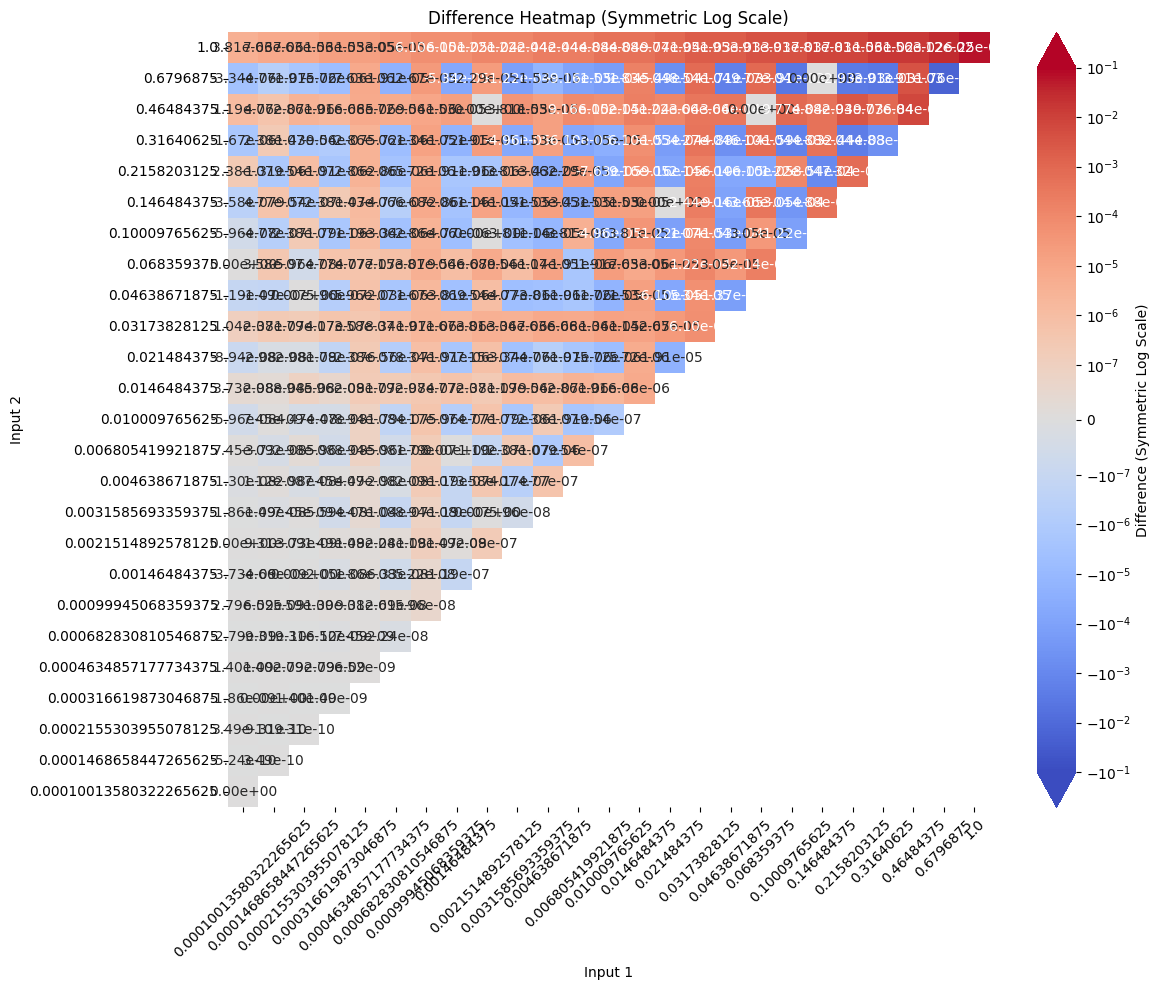

In [130]:
def bf16_lmul_naive():
    # inputs and outputs
    fp_a = pyrtl.Input(bitwidth=16, name='fp_a')
    fp_b = pyrtl.Input(bitwidth=16, name='fp_b')
    fp_out = pyrtl.Output(bitwidth=16, name='fp_out')

    sign_out = fp_a[15] ^ fp_b[15]

    unsigned_offset = pyrtl.Const(get_combined_offset(8, 7), bitwidth=15, name='offset_twos_comp')
    result_sum = fp_a[:15] + fp_b[:15] - unsigned_offset
    fp_out <<= pyrtl.concat(sign_out, pyrtl.truncate(result_sum, 15))

# analyze_circuit(
#     bf16_lmul_naive, 
#     synthesize=False,
#     optimize=False,
#     inputs=bf16_basic_inputs,
#     outputs=bf16_basic_outputs,
# )

results_df = run_testbench(
    rtl_func=bf16_lmul_naive, 
    input_names=["fp_a", "fp_b"],
    output_name="fp_out",
    start=-4,
    stop=0,
    n_values=25,
    include_special_values=False,
)

pivoted_df = reshape_testbench_results(results_df)
fig = create_diff_heatmap_a(pivoted_df)
# fig_alt = create_diff_heatmap_alt(pivoted_df)
plt.show()

In [139]:
import plotly_utils

fig = plotly_utils.imshow_logscale(pivoted_df)
fig.show()

/opt/homebrew/Caskroom/miniconda/base/envs/dsc180/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning:

divide by zero encountered in log10

/opt/homebrew/Caskroom/miniconda/base/envs/dsc180/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning:

invalid value encountered in log10



|index|input1|input2|expected|actual|diff
|-| ------- | ---- | --- | --- | --- |
0|0.00099945068359375|0.00099945068359375|9.98377799987793e-07|1.0579824447631836e-06|5.960464477539063e-08
1|0.00099945068359375|0.010009765625|1.0013580322265625e-05|1.043081283569336e-05|4.172325134277344e-07
2|0.00099945068359375|0.10009765625|0.00010013580322265625|0.000102996826171875|2.86102294921875e-06
3|0.00099945068359375|1.0|0.00099945068359375|0.00106048583984375|6.103515625e-05
4|0.010009765625|0.010009765625|0.00010013580322265625|9.918212890625e-05|-9.5367431640625e-07
5|0.010009765625|0.10009765625|0.00099945068359375|0.000949859619140625|-4.9591064453125e-05
6|0.010009765625|1.0|0.010009765625|0.010498046875|0.00048828125
7|0.10009765625|0.10009765625|0.010009765625|0.0098876953125|-0.0001220703125
8|0.10009765625|1.0|0.10009765625|0.10400390625|0.00390625
9|1.0|1.0|1.0|1.0625|0.0625


### BF16 Lmul with WireStruct


In [26]:
@pyrtl.wire_struct
class BF16Wire:
    sign: 1
    exp_mant: 15

@pyrtl.wire_struct
class BF16_LMUL_SUM:
    carry_mux: 2
    sum_bits: 15


def bf16_lmul_struct():
    # Inputs 
    em_bits = 15
    fp_a = BF16Wire(name='fp_a', concatenated_type=pyrtl.Input)
    fp_b = BF16Wire(name='fp_b', concatenated_type=pyrtl.Input)
    expected_out = BF16Wire(name='expected_out', concatenated_type=pyrtl.Input)
    
    # Calculate result sign
    sign_output = pyrtl.WireVector(1, name='sign_output')
    sign_output <<= fp_a.sign ^ fp_b.sign

    OFFSET_MINUS_BIAS = pyrtl.Const(get_combined_offset(8, 7, twos_comp=True), bitwidth=em_bits, name='offsetbias')
    
    final_sum = BF16_LMUL_SUM(
        name='final_sum', 
        BF16_LMUL_SUM=carrysave_adder(
            fp_a.exp_mant, 
            fp_b.exp_mant, 
            OFFSET_MINUS_BIAS, 
            final_adder=kogge_stone
        )
    )

    MIN_VALUE = pyrtl.Const(0, bitwidth=em_bits, name='min_value')
    MAX_VALUE = pyrtl.Const(2**em_bits-1, bitwidth=em_bits, name='max_value')
    
    exp_mant = pyrtl.WireVector(15, name='exp_mant_mux')
    exp_mant <<= pyrtl.mux(
        final_sum.carry_mux, 
        MIN_VALUE, 
        final_sum.sum_bits, 
        default=MAX_VALUE,
    )

    fp_out = BF16Wire(
        name='fp_out', 
        sign=sign_output, 
        exp_mant=exp_mant, 
        concatenated_type=pyrtl.Output
    )

    return fp_a, fp_b, fp_out

trace_list = [
    "final_sum",
]

analyze_circuit(
    bf16_lmul_struct, 
    synthesize=False,
    optimize=False,
    inputs=bf16_basic_inputs,
    outputs=bf16_basic_outputs,
    # trace_list=trace_list,
    repr_fn=lambda x: BF16(x, True),
    repr_per_name=bf16_repr_map,
    path_to_output_dir="./kai/output",
)

Step 0:
in: 0.00099945068359375 * 0.00099945068359375
	got: 1.0579824447631836e-06
	exp: 9.98377799987793e-07
	dif:	5.960464477539063e-08

Step 1:
in: 0.00099945068359375 * 0.010009765625
	got: 1.043081283569336e-05
	exp: 1.0013580322265625e-05
	dif:	4.172325134277344e-07

Step 2:
in: 0.00099945068359375 * 0.10009765625
	got: 0.000102996826171875
	exp: 0.00010013580322265625
	dif:	2.86102294921875e-06

Step 3:
in: 0.00099945068359375 * 1.0
	got: 0.00106048583984375
	exp: 0.00099945068359375
	dif:	6.103515625e-05

Step 4:
in: 0.010009765625 * 0.010009765625
	got: 9.918212890625e-05
	exp: 0.00010013580322265625
	dif:	-9.5367431640625e-07

Step 5:
in: 0.010009765625 * 0.10009765625
	got: 0.000949859619140625
	exp: 0.00099945068359375
	dif:	-4.9591064453125e-05

Step 6:
in: 0.010009765625 * 1.0
	got: 0.010498046875
	exp: 0.010009765625
	dif:	0.00048828125

Step 7:
in: 0.10009765625 * 0.10009765625
	got: 0.0098876953125
	exp: 0.010009765625
	dif:	-0.0001220703125

Step 8:
in: 0.10009765625 

In [271]:
pyrtl.reset_working_block()
bf16_lmul_struct()
sim_trace = pyrtl.SimulationTrace()
sim = pyrtl.Simulation(tracer=sim_trace)

sim.step_multiple(bf16_basic_inputs, bf16_basic_outputs)

Unexpected output on one or more steps:
 step       name expected   actual
    0     fp_out    13702    13710
    1     fp_out    14120    14127
    2     fp_out    14546    14552
    3     fp_out    14979    14987
    4     fp_out    14546    14544
    5     fp_out    14979    14969
    6     fp_out    15396    15404
    7     fp_out    15396    15394
    8     fp_out    15821    15829
    9     fp_out    16256    16264


In [266]:
len('11111101111000')

14

### FP8 Lmul


In [ ]:
def lmul_rtl():
    # Inputs 
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    # Split into sign and exp_mantissa parts
    sign_a = fp_a[7] 
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]
    exp_mantissa_b = fp_b[0:7]

    # Calculate result sign
    result_sign = sign_a ^ sign_b

    # Add exp_mantissa parts using kogge_stone adder (faster than ripple)
    # exp_mantissa_sum = kogge_stone(exp_mantissa_a, exp_mantissa_b)
    
    # For E4M3: e_bits=4, m_bits=3
    # Get the combined offset-bias constant 
    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
    
    # Add offset-bias value - this will be 8 bits including carry
    # final_sum = kogge_stone(exp_mantissa_sum, OFFSET_MINUS_BIAS)
    
    final_sum = carrysave_adder(exp_mantissa_a, exp_mantissa_b, OFFSET_MINUS_BIAS, final_adder=kogge_stone)
    # Extract carry and MSB for overflow/underflow detection
    # mux_in = final_sum[7:]  # 8th and 9th bits
    # result_bits = final_sum[0:7]  # lower 7 bits

    # Select result based on carry and MSB:
    # carry=1: overflow -> 0x7F
    # carry=0, msb=0: underflow -> 0x00
    # carry=0, msb=1: normal -> result_bits
    MAX_VALUE = pyrtl.Const(0x7F, 7)
    
    mantissa_result = pyrtl.mux(final_sum[7:], pyrtl.Const(0, bitwidth=7), final_sum[0:7], default=MAX_VALUE)

    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

analyze_circuit(lmul_rtl)

Pre Optimization:
The total block timing delay is  1541.4399999999998
Estimated Area of block 0.000437778 sq mm

Post Optimization:
The total block timing delay is  1406.37
Estimated Area of block 0.000259182 sq mm

Max frequency of block:  558.8559101806782 MHz


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 01110000 * fp_b: 01110000 = fp_out: 01111111
fp_a: 00000001 * fp_b: 00000001 = fp_out: 00000000
fp_a: 11000000 * fp_b: 01000000 = fp_out: 11001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000


### FP8 Lmul using basic adders


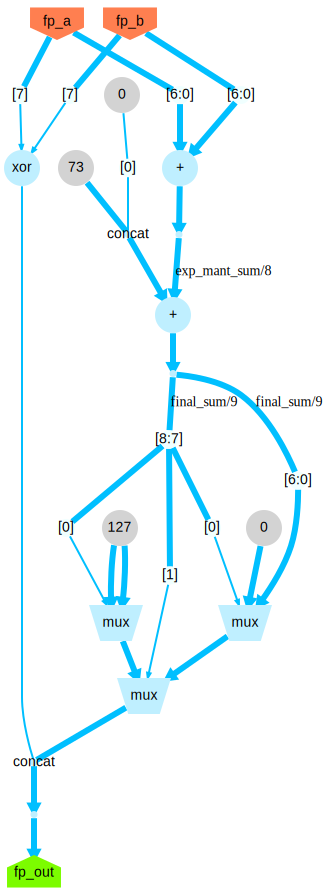

Pre Optimization:
The total block timing delay is  3025.0100000000007
Estimated Area of block 0.0004356 sq mm

Post Optimization:
The total block timing delay is  2580.84
Estimated Area of block 0.000233046 sq mm

Max frequency of block:  337.40012956164975 MHz


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 01110000 * fp_b: 01110000 = fp_out: 01111111
fp_a: 00000001 * fp_b: 00000001 = fp_out: 00000000
fp_a: 11000000 * fp_b: 01000000 = fp_out: 11001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000


In [ ]:
def lmul_naive():
    # Inputs 
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
    MAX_VALUE = pyrtl.Const(0x7F, 7)

    exp_mant_sum = pyrtl.WireVector(bitwidth=8, name='exp_mant_sum')
    final_sum = pyrtl.WireVector(bitwidth=9, name='final_sum')
    
    # Split into sign and exp_mantissa parts
    sign_a = fp_a[7] 
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]
    exp_mantissa_b = fp_b[0:7]

    # Calculate result sign
    result_sign = sign_a ^ sign_b
    
    exp_mant_sum <<= exp_mantissa_a + exp_mantissa_b
    final_sum <<= exp_mant_sum + OFFSET_MINUS_BIAS
    
    mantissa_result = pyrtl.mux(final_sum[7:], pyrtl.Const(0, bitwidth=7), final_sum[0:7], default=MAX_VALUE)

    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

analyze_circuit(lmul_naive, svg=True, display_pre_opt=True)

### FP8 Lmul Pipelined


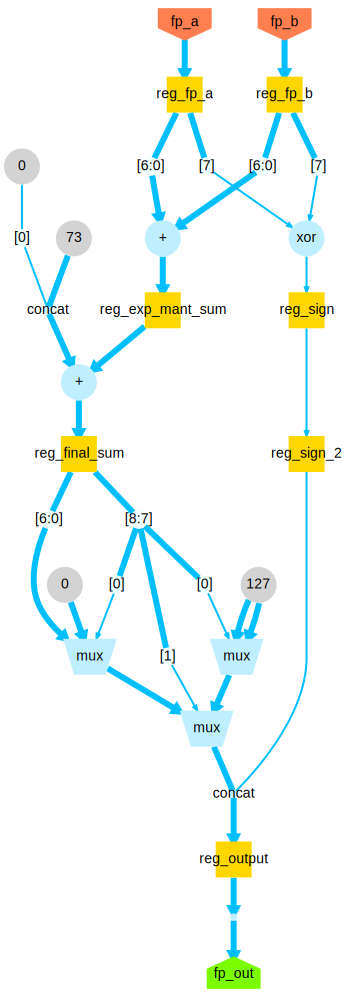

Pre Optimization:
The total block timing delay is  2472.8
Estimated Area of block 0.0007727544 sq mm

Post Optimization:
The total block timing delay is  1953.0999999999997
Estimated Area of block 0.0005702004 sq mm

Max frequency of block:  428.06386712897574 MHz


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 00000000
fp_a: 01110000 * fp_b: 01110000 = fp_out: 00000000
fp_a: 00000001 * fp_b: 00000001 = fp_out: 00000000
fp_a: 11000000 * fp_b: 01000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 01001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 01111111
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 11001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000


In [ ]:
class PipelinedLMUL:
    def __init__(self):
        # Inputs and Outputs
        self.fp_a = pyrtl.Input(8, 'fp_a')
        self.fp_b = pyrtl.Input(8, 'fp_b')
        self.fp_out = pyrtl.Output(8, 'fp_out')

        # Constants
        self.OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
        self.MAX_VALUE = pyrtl.Const(0x7F, 7)

        # Pipeline Registers
        # Stage 0 -> 1
        self.reg_fp_a = pyrtl.Register(8, 'reg_fp_a')
        self.reg_fp_b = pyrtl.Register(8, 'reg_fp_b')
        
        # Stage 1 -> 2
        self.reg_sign = pyrtl.Register(1, 'reg_sign')
        self.reg_exp_mant_sum = pyrtl.Register(8, 'reg_exp_mant_sum')
        
        # Stage 2 -> 3
        self.reg_final_sum = pyrtl.Register(9, 'reg_final_sum')
        self.reg_sign_2 = pyrtl.Register(1, 'reg_sign_2')
        
        # Stage 3 -> output
        self.reg_output = pyrtl.Register(8, 'reg_output')

        # Build pipeline
        self._build_pipeline()

    def stage0_input(self):
        """Input registration stage"""
        self.reg_fp_a.next <<= self.fp_a
        self.reg_fp_b.next <<= self.fp_b

    def stage1_split_and_add(self):
        """Split inputs and perform first addition"""
        # Split registered inputs
        sign_a = self.reg_fp_a[7]
        sign_b = self.reg_fp_b[7]
        exp_mantissa_a = self.reg_fp_a[0:7]
        exp_mantissa_b = self.reg_fp_b[0:7]
        
        # Calculate and register sign
        self.reg_sign.next <<= sign_a ^ sign_b
        
        # First addition and register result
        exp_mant_sum = exp_mantissa_a + exp_mantissa_b
        self.reg_exp_mant_sum.next <<= exp_mant_sum

    def stage2_offset_add(self):
        """Perform second addition with offset"""
        # Add offset and register result
        self.reg_final_sum.next <<= self.reg_exp_mant_sum + self.OFFSET_MINUS_BIAS
        # Pass through sign
        self.reg_sign_2.next <<= self.reg_sign

    def stage3_output_format(self):
        """Format final output"""
        # Mux selection based on overflow/underflow
        mantissa_result = pyrtl.mux(
            self.reg_final_sum[7:],  # Select bits for mux control
            pyrtl.Const(0, bitwidth=7),  # Underflow case
            self.reg_final_sum[0:7],  # Normal case
            default=self.MAX_VALUE  # Overflow case
        )
        
        # Combine sign and mantissa
        self.reg_output.next <<= pyrtl.concat(self.reg_sign_2, mantissa_result)

    def _build_pipeline(self):
        """Connect all pipeline stages"""
        self.stage0_input()
        self.stage1_split_and_add()
        self.stage2_offset_add()
        self.stage3_output_format()
        # Connect final register to output
        self.fp_out <<= self.reg_output

analyze_circuit(PipelinedLMUL, svg=True, display_pre_opt=True)

### Faster Pipelined LMUL


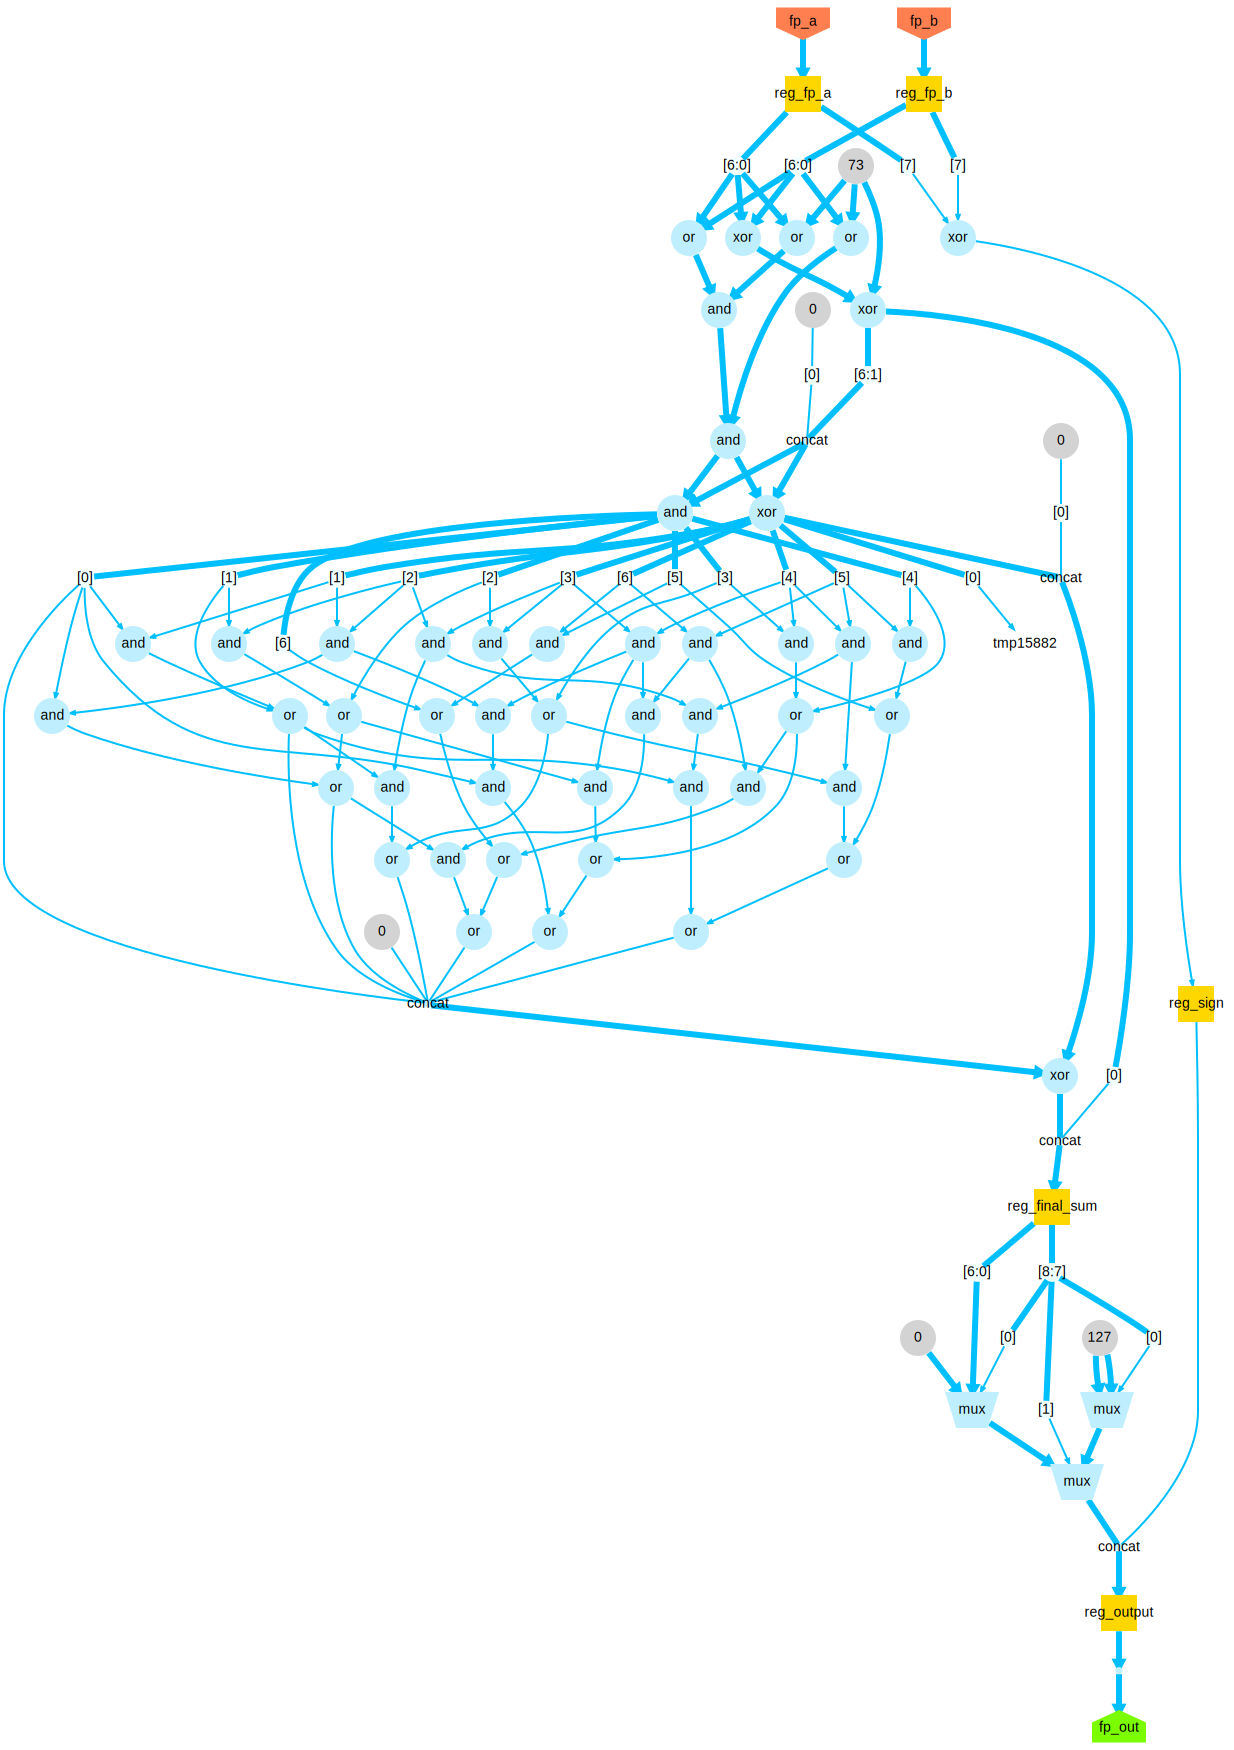

Pre Optimization:
The total block timing delay is  1085.34
Estimated Area of block 0.0007043652 sq mm

Post Optimization:
The total block timing delay is  1085.34
Estimated Area of block 0.0005257692 sq mm

Max frequency of block:  681.0411757494859 MHz


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 00000000
fp_a: 01110000 * fp_b: 01110000 = fp_out: 00000000
fp_a: 00000001 * fp_b: 00000001 = fp_out: 00000000
fp_a: 11000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 01111111
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 11001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000


In [ ]:
class FastPipelinedLMUL:
    def __init__(self):
        # Inputs and Outputs
        self.fp_a = pyrtl.Input(8, 'fp_a')
        self.fp_b = pyrtl.Input(8, 'fp_b')
        self.fp_out = pyrtl.Output(8, 'fp_out')

        # Constants
        self.OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
        self.MAX_VALUE = pyrtl.Const(0x7F, 7)

        # Pipeline Registers
        # Stage 0 -> 1
        self.reg_fp_a = pyrtl.Register(8, 'reg_fp_a')
        self.reg_fp_b = pyrtl.Register(8, 'reg_fp_b')
        
        # Stage 1 -> 2
        self.reg_sign = pyrtl.Register(1, 'reg_sign')
        self.reg_final_sum = pyrtl.Register(9, 'reg_final_sum')
        
        # Stage 2 -> output
        self.reg_output = pyrtl.Register(8, 'reg_output')

        # Build pipeline
        self._build_pipeline()

    def stage0_input(self):
        """Input registration stage"""
        self.reg_fp_a.next <<= self.fp_a
        self.reg_fp_b.next <<= self.fp_b

    def stage1_split_and_add(self):
        """Split inputs and perform additions"""
        # Split registered inputs
        sign_a = self.reg_fp_a[7]
        sign_b = self.reg_fp_b[7]
        exp_mantissa_a = self.reg_fp_a[0:7]
        exp_mantissa_b = self.reg_fp_b[0:7]
        
        # Calculate and register sign
        self.reg_sign.next <<= sign_a ^ sign_b
        
        # First addition and register result
        final_sum = carrysave_adder(
            exp_mantissa_a, 
            exp_mantissa_b, 
            self.OFFSET_MINUS_BIAS, 
            final_adder=kogge_stone
        )

        self.reg_final_sum.next <<= final_sum

    def stage2_output_format(self):
        """Format final output"""
        # Mux selection based on overflow/underflow
        mantissa_result = pyrtl.mux(
            self.reg_final_sum[7:],  # Select bits for mux control
            pyrtl.Const(0, bitwidth=7),  # Underflow case
            self.reg_final_sum[0:7],  # Normal case
            default=self.MAX_VALUE  # Overflow case
        )
        
        # Combine sign and mantissa
        self.reg_output.next <<= pyrtl.concat(self.reg_sign, mantissa_result)

    def _build_pipeline(self):
        """Connect all pipeline stages"""
        self.stage0_input()
        self.stage1_split_and_add()
        self.stage2_output_format()
        # Connect final register to output
        self.fp_out <<= self.reg_output

analyze_circuit(FastPipelinedLMUL, svg=True, display_pre_opt=True)

### FP8 Lmul with WireStruct


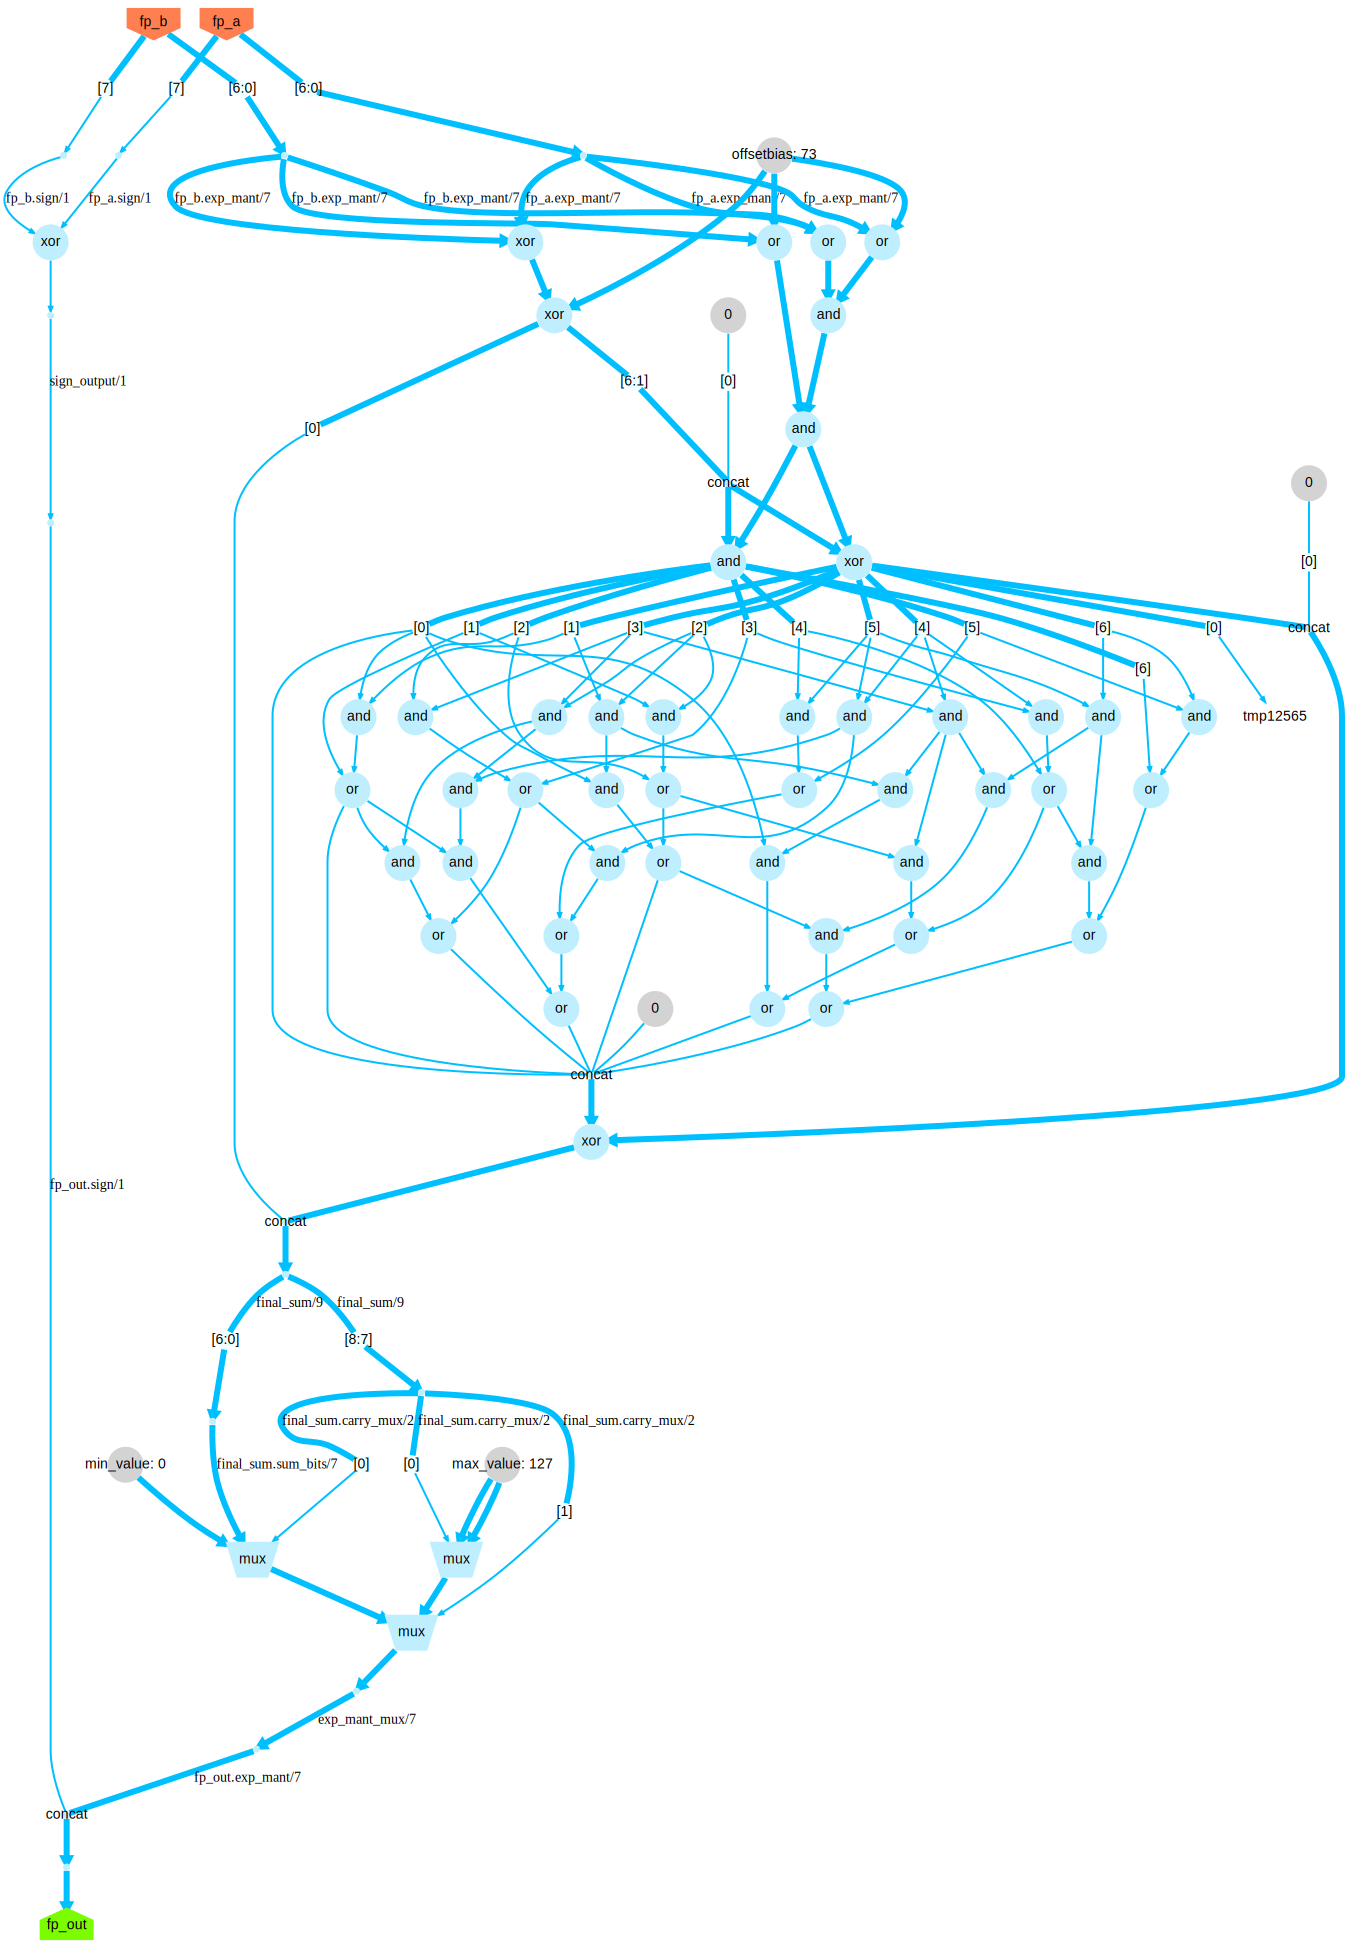

Pre Optimization:
The total block timing delay is  1541.4399999999998
Estimated Area of block 0.000437778 sq mm

Post Optimization:
The total block timing delay is  1406.37
Estimated Area of block 0.000259182 sq mm

Max frequency of block:  558.8559101806782 MHz


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 01110000 * fp_b: 01110000 = fp_out: 01111111
fp_a: 00000001 * fp_b: 00000001 = fp_out: 00000000
fp_a: 11000000 * fp_b: 01000000 = fp_out: 11001001


In [ ]:
@pyrtl.wire_struct
class FP8:
    sign: 1
    exp_mant: 7

@pyrtl.wire_struct
class FP8_LMUL_SUM:
    carry_mux: 2
    sum_bits: 7


def lmul_struct():
    # Inputs 
    fp_a = FP8(name='fp_a', concatenated_type=pyrtl.Input)
    fp_b = FP8(name='fp_b', concatenated_type=pyrtl.Input)
    
    # Calculate result sign
    sign_output = pyrtl.WireVector(1, name='sign_output')
    sign_output <<= fp_a.sign ^ fp_b.sign

    # Add exp_mantissa parts using kogge_stone adder (faster than ripple)
    # exp_mantissa_sum = kogge_stone(exp_mantissa_a, exp_mantissa_b)
    
    # For E4M3: e_bits=4, m_bits=3
    # Get the combined offset-bias constant 
    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7, name='offsetbias')
    
    # Add offset-bias value - this will be 8 bits including carry
    # final_sum = kogge_stone(exp_mantissa_sum, OFFSET_MINUS_BIAS)
    
    final_sum = FP8_LMUL_SUM(
        name='final_sum', 
        FP8_LMUL_SUM=carrysave_adder(
            fp_a.exp_mant, 
            fp_b.exp_mant, 
            OFFSET_MINUS_BIAS, 
            final_adder=kogge_stone
        )
    )

    MIN_VALUE = pyrtl.Const(0, bitwidth=7, name='min_value')
    MAX_VALUE = pyrtl.Const(0x7F, bitwidth=7, name='max_value')
    
    exp_mant = pyrtl.WireVector(7, name='exp_mant_mux')
    exp_mant <<= pyrtl.mux(
        final_sum.carry_mux, 
        MIN_VALUE, 
        final_sum.sum_bits, 
        default=MAX_VALUE,
    )

    fp_out = FP8(
        name='fp_out', 
        sign=sign_output, 
        exp_mant=exp_mant, 
        concatenated_type=pyrtl.Output
    )

    return fp_a, fp_b, fp_out

analyze_circuit(lmul_struct, svg=True, display_pre_opt=True)

### Dynamic Precision Lmul


#### Floating Point Format Helpers


In [ ]:
def get_float_constants(exp_bits: int, mant_bits: int) -> dict:
    """
    Generate floating point format constants based on exponent and mantissa bits.
    
    Args:
        exp_bits: Number of exponent bits
        mant_bits: Number of mantissa bits
        
    Returns:
        Dictionary containing format constants including:
        - Special values (nan, inf, zero etc)
        - Max/min normal values
        - Format specifications
    """
    total_bits = 1 + exp_bits + mant_bits  # sign + exp + mant
    
    # Calculate key bit patterns
    exp_mask = ((1 << exp_bits) - 1) << mant_bits
    mant_mask = (1 << mant_bits) - 1
    sign_bit = 1 << (total_bits - 1)
    
    # Special exponent values
    exp_bias = (1 << (exp_bits - 1)) - 1
    exp_all_ones = (1 << exp_bits) - 1
    
    # Calculate constants
    constants = {
        'nan': (exp_all_ones << mant_bits) | (1 << (mant_bits-1)),  # Exponent all 1s, MSB of mantissa 1
        'inf': exp_all_ones << mant_bits,  # Exponent all 1s, mantissa 0
        'neg_inf': sign_bit | (exp_all_ones << mant_bits),  # Sign 1, exponent all 1s, mantissa 0
        'zero': 0x0,  # All bits 0
        'neg_zero': sign_bit,  # Sign 1, all else 0
        
        # Max values use all 1s in mantissa and max normal exponent
        'max_pos': ((exp_all_ones - 1) << mant_bits) | mant_mask,
        'max_neg': sign_bit | ((exp_all_ones - 1) << mant_bits) | mant_mask,
        
        # Min normal values use minimum normal exponent (1) and 0 mantissa
        'min_pos': 1 << mant_bits,
        'min_neg': sign_bit | (1 << mant_bits),
        
        # Format specifications
        'bits': total_bits,
        'exponent_bits': exp_bits,
        'mantissa_bits': mant_bits,
        'exponent_bias': exp_bias
    }
    
    return constants


# Common formats
bf16 = get_float_constants(8, 7)    # bfloat16
fp16 = get_float_constants(5, 10)   # IEEE half precision
fp8e4m3 = get_float_constants(4, 3) # 8-bit float with 4 exp, 3 mantissa
fp32 = get_float_constants(8, 23)   # IEEE single precision

{k: format(v, '016b') for k, v in bf16.items()}
{k: format(v, '08b') for k, v in fp8e4m3.items()}

{'nan': '01111100',
 'inf': '01111000',
 'neg_inf': '11111000',
 'zero': '00000000',
 'neg_zero': '10000000',
 'max_pos': '01110111',
 'max_neg': '11110111',
 'min_pos': '00001000',
 'min_neg': '10001000',
 'bits': '00001000',
 'exponent_bits': '00000100',
 'mantissa_bits': '00000011',
 'exponent_bias': '00000111'}

#### Dynamic Lmul PyRTL Implementation


Pre Optimization:
The total block timing delay is  1541.4399999999998
Estimated Area of block 0.000437778 sq mm

Post Optimization:
The total block timing delay is  1406.37
Estimated Area of block 0.000259182 sq mm



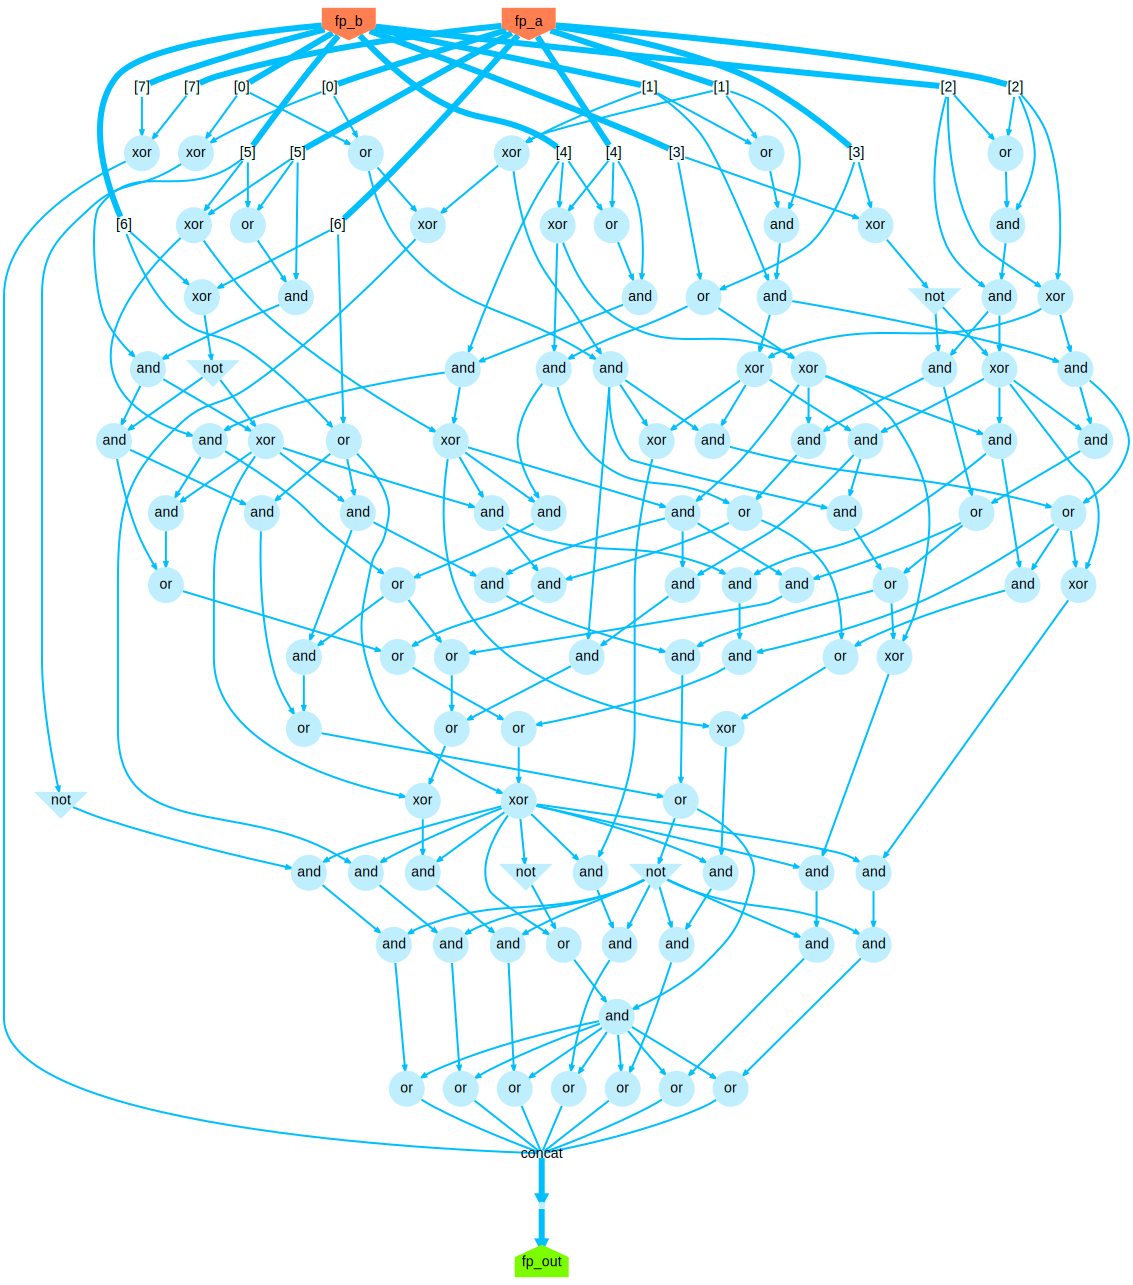

In [ ]:
def lmul_dynamic(EXP_BITS, MANT_BITS):
    exp_mant_bits = EXP_BITS + MANT_BITS
    total_bits = 1 + exp_mant_bits
    # Inputs 
    fp_a = pyrtl.Input(total_bits, 'fp_a')
    fp_b = pyrtl.Input(total_bits, 'fp_b')
    fp_out = pyrtl.Output(total_bits, 'fp_out')

    # Split into sign and exp_mantissa parts
    sign_a = fp_a[exp_mant_bits] 
    sign_b = fp_b[exp_mant_bits]
    exp_mantissa_a = fp_a[0:exp_mant_bits]
    exp_mantissa_b = fp_b[0:exp_mant_bits]

    # Calculate result sign
    result_sign = sign_a ^ sign_b

    # Add exp_mantissa parts using kogge_stone adder (faster than ripple)
    # exp_mantissa_sum = kogge_stone(exp_mantissa_a, exp_mantissa_b)
    
    # For E4M3: e_bits=4, m_bits=3
    # Get the combined offset-bias constant 
    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(EXP_BITS, MANT_BITS), bitwidth=exp_mant_bits)
    
    # Add offset-bias value - this will be 8 bits including carry
    # final_sum = kogge_stone(exp_mantissa_sum, OFFSET_MINUS_BIAS)
    
    final_sum = carrysave_adder(exp_mantissa_a, exp_mantissa_b, OFFSET_MINUS_BIAS, final_adder=kogge_stone)
    # Extract carry and MSB for overflow/underflow detection
    # mux_in = final_sum[7:]  # 8th and 9th bits
    # result_bits = final_sum[0:7]  # lower 7 bits

    # Select result based on carry and MSB:
    # carry=1: overflow -> 0x7F
    # carry=0, msb=0: underflow -> 0x00
    # carry=0, msb=1: normal -> result_bits
    MAX_VALUE = pyrtl.Const(get_ma, 7)
    
    mantissa_result = pyrtl.mux(final_sum[7:], pyrtl.Const(0, bitwidth=7), final_sum[0:7], default=MAX_VALUE)

    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

# Create the hardware
pyrtl.reset_working_block()
fp_a, fp_b, fp_out = lmul_rtl()

pyrtl.synthesize()

# Generating timing analysis information
print("Pre Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()
logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
est_area = logic_area + mem_area
print("Estimated Area of block", est_area, "sq mm")
print()

pyrtl.optimize()

print("Post Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()
logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
est_area = logic_area + mem_area
print("Estimated Area of block", est_area, "sq mm")
print()

svg = pyrtl.block_to_svg()
display_svg(svg, raw=True)

### Pipelining


In [ ]:
""" Example 5: Making use of PyRTL and Introspection. """

import pyrtl


# The following example shows how PyRTL can be used to make some interesting
# hardware structures using Python introspection.  In particular, this example
# makes a N-stage pipeline structure.  Any specific pipeline is then a derived
# class of SimplePipeline where methods with names starting with "stage" are
# stages, and new members with names not starting with "_" are to be registered
# for the next stage.

class SimplePipeline(object):
    """ Pipeline builder with auto generation of pipeline registers. """

    def __init__(self):
        self._pipeline_register_map = {}
        self._current_stage_num = 0
        stage_list = [method for method in dir(self) if method.startswith('stage')]
        for stage in sorted(stage_list):
            stage_method = getattr(self, stage)
            stage_method()
            self._current_stage_num += 1

    def __getattr__(self, name):
        try:
            return self._pipeline_register_map[self._current_stage_num][name]
        except KeyError:
            raise pyrtl.PyrtlError(
                'error, no pipeline register "%s" defined for stage %d'
                % (name, self._current_stage_num))

    def __setattr__(self, name, value):
        if name.startswith('_'):
            # do not do anything tricky with variables starting with '_'
            object.__setattr__(self, name, value)
        else:
            next_stage = self._current_stage_num + 1
            pipereg_id = str(self._current_stage_num) + 'to' + str(next_stage)
            rname = 'pipereg_' + pipereg_id + '_' + name
            new_pipereg = pyrtl.Register(bitwidth=len(value), name=rname)
            if next_stage not in self._pipeline_register_map:
                self._pipeline_register_map[next_stage] = {}
            self._pipeline_register_map[next_stage][name] = new_pipereg
            new_pipereg.next <<= value

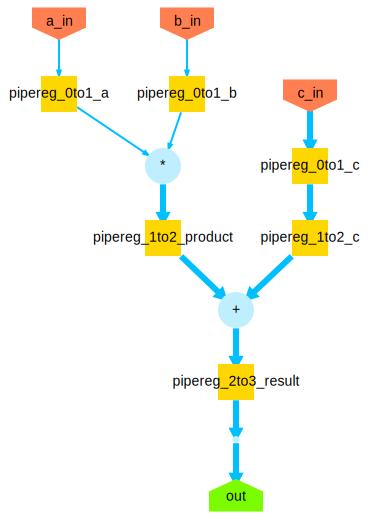

In [ ]:
pyrtl.reset_working_block()

class FloatingPointMAC(SimplePipeline):
    def __init__(self):
        self._out = pyrtl.Output(3, 'out')
        super(FloatingPointMAC, self).__init__()
    def stage0(self):
        # Input stage - receive operands
        self.a = pyrtl.Input(1, 'a_in')
        self.b = pyrtl.Input(1, 'b_in')
        self.c =  pyrtl.Input(2, 'c_in')

    def stage1(self):
        # Multiply stage
        self.product = self.a * self.b
        self.c = self.c  # Pass through c to next stage

    def stage2(self):
        # Add stage
        self.result = self.product + self.c

    def stage3(self):
        # Output stage
        self._out <<= self.result

simplepipeline = FloatingPointMAC()
svg = pyrtl.block_to_svg(split_state=False)
display_svg(svg, raw=True)

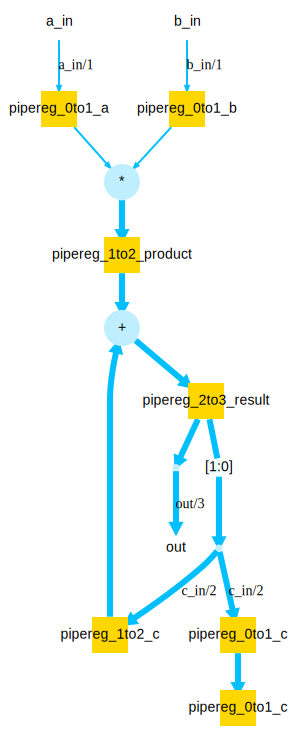

In [ ]:
pyrtl.reset_working_block()

class FloatingPointMAC(SimplePipeline):
    def __init__(self):
        self._out = pyrtl.WireVector(3, 'out')
        self._a = pyrtl.WireVector(1, 'a_in')
        self._b = pyrtl.WireVector(1, 'b_in')
        self._c =  pyrtl.WireVector(2, 'c_in')
        super(FloatingPointMAC, self).__init__()
        
    def stage0(self):
        # Input stage - receive operands
        # self.a = pyrtl.Input(1, 'a_in')
        # self.b = pyrtl.Input(1, 'b_in')
        # self.c =  pyrtl.Input(2, 'c_in')

        self.a = self._a
        self.b = self._b
        self.c = self._c

    def stage1(self):
        # Multiply stage
        self.product = self.a * self.b
        # self.c = self.c  # Pass through c to next stage

        # self.product = self._a * self._b
        self.c = self._c  # Pass through c to next stage

    def stage2(self):
        # Add stage
        
        self.result = self.product + self.c
        # self._c <<= self.result

    def stage3(self):
        # Output stage
        # global out
        self._out <<= self.result
        self._c <<= self.result

simplepipeline = FloatingPointMAC()
svg = pyrtl.block_to_svg(split_state=False)
display_svg(svg, raw=True)

In [ ]:
0xc

12

<IPython.core.display.Latex object>

<IPython.core.display.Javascript object>

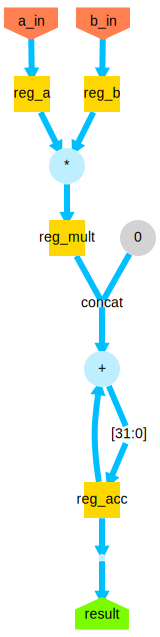

In [ ]:
import pyrtl

# Reset working block
pyrtl.reset_working_block()

# Input/Output declarations
a_in = pyrtl.Input(8, 'a_in')
b_in = pyrtl.Input(8, 'b_in')
# reset = pyrtl.Input(1, 'reset')
result = pyrtl.Output(32, 'result')

class PipelinedMAC:
    def __init__(self):
        # Stage 0 -> 1: Input registers
        self.reg_a = pyrtl.Register(8, 'reg_a')
        self.reg_b = pyrtl.Register(8, 'reg_b')
        
        # Stage 1 -> 2: Multiplication result register
        self.reg_mult = pyrtl.Register(16, 'reg_mult')
        
        # Stage 2: Accumulator register
        self.reg_acc = pyrtl.Register(32, 'reg_acc')
        
        # Build the pipeline
        self._build_pipeline()
    
    def _build_pipeline(self):
        # Stage 0: Register inputs
        self.reg_a.next <<= a_in
        self.reg_b.next <<= b_in
        
        # Stage 1: Multiplication
        mult_result = self.reg_a * self.reg_b  # 8x8 = 16 bits
        self.reg_mult.next <<= mult_result
        
        # Stage 2: Accumulation
        # Zero extend multiplication result to 32 bits
        extended_mult = pyrtl.concat(pyrtl.Const(0, 16), self.reg_mult)
        
        # Create accumulator logic with reset
        self.reg_acc.next <<= self.reg_acc + extended_mult
        global result
        # Connect accumulator to output
        result <<= self.reg_acc

# Instantiate the MAC unit
mac = PipelinedMAC()

# Optional: Print the working block to see the design
print(pyrtl.working_block())

# Optional: Add simulation code for testing
if __name__ == '__main__':
    sim = pyrtl.Simulation()
    
    # Test vectors
    sim_inputs = {
        'a_in':    [1, 2, 3, 0, 0, 0],
        'b_in':    [2, 3, 4, 0, 0, 0],
        # 'reset':   [0, 0, 0, 0, 0]  # Reset first cycle only
    }
    
    # Run simulation
    sim.step_multiple(sim_inputs)
    
    # Display trace
    sim.tracer.render_trace()
    svg = pyrtl.block_to_svg(split_state=False)
    display_svg(svg, raw=True)


### Floating Point Adder


In [ ]:
import pyrtl
from pyrtl import conditional_assignment

# First, let's create a wire_struct for floating point numbers
@pyrtl.wire_struct
class Float32:
    sign: 1
    exponent: 8
    mantissa: 23

class FloatAdder:
    def __init__(self):
        # Input/Output declarations
        self.operand1 = Float32(name='operand1', concatenated_type=pyrtl.Input)
        self.operand2 = Float32(name='operand2', concatenated_type=pyrtl.Input)
        self.sign_out = pyrtl.WireVector(1, name='sign_out')
        self.exponent_out = pyrtl.WireVector(8, name='exponent_out')
        self.mantissa_out = pyrtl.WireVector(23, name='mantissa_out')
        
        # Pipeline control signals
        self.busy1 = pyrtl.Register(1, 'busy1')
        self.busy2 = pyrtl.Register(1, 'busy2')
        self.busy3 = pyrtl.Register(1, 'busy3')
        self.done1 = pyrtl.WireVector(1, 'done1')
        self.done2 = pyrtl.WireVector(1, 'done2')
        self.done3 = pyrtl.WireVector(1, 'done3')

        # Internal registers for pipeline stages
        self.mantissa1_reg = pyrtl.Register(24, 'mantissa1_reg')  # 23 + hidden bit
        self.mantissa2_reg = pyrtl.Register(24, 'mantissa2_reg')
        self.exponent1_reg = pyrtl.Register(8, 'exponent1_reg')
        self.exponent2_reg = pyrtl.Register(8, 'exponent2_reg')
        
        # Stage 1: Compare and Shift registers
        self.shifted_mantissa1 = pyrtl.Register(24, 'shifted_mantissa1')
        self.shifted_mantissa2 = pyrtl.Register(24, 'shifted_mantissa2')
        self.new_exponent = pyrtl.Register(8, 'new_exponent')
        
        # Stage 2: Addition registers
        self.mantissa_sum = pyrtl.Register(25, 'mantissa_sum')  # Extra bit for overflow
        
        # Stage 3: Normalization registers
        self.final_mantissa = pyrtl.Register(24, 'final_mantissa')
        self.final_exponent = pyrtl.Register(8, 'final_exponent')
        
        # Build the pipeline
        self._build_pipeline()

    def _compare_and_shift(self):
        """Stage 1: Compare exponents and shift mantissas"""
        with conditional_assignment:
            with ~self.busy1:
                # Load new values
                self.mantissa1_reg.next |= pyrtl.concat(pyrtl.Const(1, 1), self.operand1.mantissa)
                self.mantissa2_reg.next |= pyrtl.concat(pyrtl.Const(1, 1), self.operand2.mantissa)
                self.exponent1_reg.next |= self.operand1.exponent
                self.exponent2_reg.next |= self.operand2.exponent
                self.busy1.next |= 1

            with self.busy1:
                # Compare exponents and shift mantissas
                exp_diff = self.exponent1_reg - self.exponent2_reg
                exp_1_greater = self.exponent1_reg > self.exponent2_reg
                
                with exp_1_greater:
                    self.shifted_mantissa1.next |= self.mantissa1_reg
                    self.shifted_mantissa2.next |= pyrtl.shift_right_logical(self.mantissa2_reg, exp_diff)
                    self.new_exponent.next |= self.exponent1_reg + 1
                
                with ~exp_1_greater:
                    diff = self.exponent2_reg - self.exponent1_reg
                    self.shifted_mantissa2.next |= self.mantissa2_reg
                    self.shifted_mantissa1.next |= pyrtl.shift_right_logical(self.mantissa1_reg, diff)
                    self.new_exponent.next |= self.exponent2_reg + 1
                
                self.done1 |= 1
                self.busy1.next |= 0

    def _add_mantissas(self):
        """Stage 2: Add the aligned mantissas"""
        with conditional_assignment:
            with self.done1 & ~self.busy2:
                self.mantissa_sum.next |= self.shifted_mantissa1 + self.shifted_mantissa2
                self.busy2.next |= 1
                self.done2 |= 1
                self.busy2.next |= 0

    def _normalize(self):
        """Stage 3: Normalize the result"""
        with conditional_assignment:
            with self.done2 & ~self.busy3:
                # Initial normalization
                self.final_mantissa.next |= self.mantissa_sum[24:1]
                self.final_exponent.next |= self.new_exponent
                self.busy3.next |= 1

            with self.busy3:
                # Normalize until leading 1
                leading_zero = ~self.final_mantissa[23]
                with leading_zero:
                    self.final_mantissa.next |= pyrtl.shift_left_logical(self.final_mantissa, 1)
                    self.final_exponent.next |= self.final_exponent - 1
                with ~leading_zero:
                    self.done3 |= 1
                    self.busy3.next |= 0

    def _build_pipeline(self):
        """Connect all pipeline stages"""
        self._compare_and_shift()
        self._add_mantissas()
        self._normalize()
        
        # Connect final output
        with conditional_assignment:
            with self.done3:
                self.sign_out |= self.operand1.sign  # Simplified - should handle sign properly
                self.exponent_out |= self.final_exponent
                self.mantissa_out |= self.final_mantissa[22:0]
                # self.sum_out = Float32(sign=self.sign_out, exponent=self.exponent_out, mantissa=self.mantissa_out)

def test_float_adder():
    # Create the adder
    adder = FloatAdder()
    
    # Create simulation
    sim_trace = pyrtl.SimulationTrace()
    sim = pyrtl.Simulation(tracer=sim_trace)
    
    # Test vectors
    test_cases = [
        # op1: (sign, exp, mantissa), op2: (sign, exp, mantissa)
        ((0, 0x7F, 0), (0, 0x7F, 0)),  # 1.0 + 1.0
        ((0, 0x80, 0), (0, 0x7F, 0)),  # 2.0 + 1.0
    ]
    
    for op1, op2 in test_cases:
        # Create input dictionary
        sim.step({
            'operand1': pyrtl.concat_list([op1[0], op1[1], op1[2]]),
            'operand2': pyrtl.concat_list([op2[0], op2[1], op2[2]])
        })
    
    # Display the trace
    sim_trace.render_trace()

if __name__ == "__main__":
    test_float_adder()


PyrtlInternalError: error, net op "x" not from acceptable set {'~', 'r', 'w', 's', 'c', 'm', '^', '@', '|', '&', 'n'}